# Bridge Vulnerability Index — N1/N2 Network, Bangladesh

This notebook computes a composite **Vulnerability Index (VI)** for every bridge on Bangladesh's N1/N2 transport corridor.  
The VI integrates four risk dimensions:

| Dimension | Data source | Raw classes |
|-----------|-------------|-------------|
| Structural condition | BMMS (Bangladesh Bridge Management System) | A – D |
| Flood hazard | BARC flood-zone raster | A – D |
| Seismic hazard | BNBC 2020 seismic-zone map | I – III |
| Riverbank erosion | BARC erosion raster | presence / absence |

The resulting CSV (`vulnerability_index.csv`) feeds directly into the simulation model as the primary driver of per-bridge failure probabilities.

**Key methodological references**
- Kappes, Papathoma-Köhle & Keiler (2012) — indicator-based physical vulnerability for multiple hazards  
- UNDP Bangladesh Multi-Hazard Risk Analysis (2021) — Bangladesh-specific hazard weighting context  
- Jafino, Kwakkel & Verbraeck (2020) — transport network criticality metrics  
- BNBC 2020 — seismic zone classification for Bangladesh  
- Sarker et al. (2014) — riverbank erosion impact on bridge foundations in Bangladesh

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Ordinal-to-numeric mappings and hazard weights

Each qualitative risk class is first converted to an **ordinal integer**, then
**normalised to [0, 1]** by dividing by the maximum value in that scale.  
This places every factor on a comparable unit-free scale before the weights are applied.

### Why these weights?

The four normalised components are combined with a **weighted additive model** (Kappes et al., 2012),
which is the standard approach when hazard dimensions differ in severity and data resolution:

$$VI = w_1 \cdot \frac{EQ}{3} + w_2 \cdot \frac{FL}{4} + w_3 \cdot ER + w_4 \cdot \frac{CO}{4}$$

with $\sum w_i = 1$, so $VI \in [0, 1]$.

| Dimension | Weight | Justification |
|-----------|--------|---------------|
| Structural condition | **0.35** | Intrinsic structural weakness is the primary determinant of a bridge's susceptibility to *any* hazard — a well-maintained (A) bridge resists the same environmental stress far better than a degraded (D) bridge (FHWA Bridge Health Index, 2016; BMMS documentation). |
| Flood hazard | **0.30** | Bangladesh experiences near-annual flooding affecting 20–70 % of its land area; hydraulic scour and debris impact are the leading causes of bridge damage (SPARRSO, 2020; UNDP Multi-Hazard Risk Analysis, 2021). |
| Riverbank erosion | **0.20** | Riverbank erosion directly undermines bridge abutments and piers; it is the principal mode of catastrophic collapse in riverine Bangladesh (Sarker et al., 2014). Even the binary presence/absence signal captures a high-consequence foundation risk. |
| Seismic hazard | **0.15** | Bangladesh is seismically active, but major bridge collapses attributable *solely* to earthquakes are less frequent than flood/erosion events over decadal timescales (Ansary & Ara, 2004; BNBC 2020). |

> **Limitation**: the erosion field in the source data is binary (present / absent); a continuous erosion-intensity score would increase the discriminatory power of the index. The weight of 0.20 reflects this limitation — it is deliberately lower than flood, which has a four-class resolution.

In [2]:
# ---------------------------------------------------------------------------
# Seismic-zone mapping  (Bangladesh National Building Code, BNBC 2020)
# Zone I  = highest PGA (> 0.25 g)  — north-east Bangladesh
# Zone II = moderate PGA (0.15–0.25 g)
# Zone III= lowest PGA  (< 0.15 g)  — south-west Bangladesh
# Higher zone *number* in BNBC = lower hazard, so we invert: I→3, III→1.
# ---------------------------------------------------------------------------
EARTHQUAKE_MAP = {"I": 3, "II": 2, "III": 1}
EARTHQUAKE_MAX = 3  # normalisation denominator

# ---------------------------------------------------------------------------
# Flood-hazard classes  (BARC flood-zone raster)
# A = very high inundation (> 3 m, extended duration)
# B = high inundation  (1–3 m)
# C = moderate inundation (< 1 m)
# D = low / rarely flooded
# ---------------------------------------------------------------------------
FLOOD_MAP = {"A": 4, "B": 3, "C": 2, "D": 1}
FLOOD_MAX = 4

# ---------------------------------------------------------------------------
# Riverbank erosion  (BARC erosion raster)
# The source layer only distinguishes active erosion corridors from stable
# land.  Bridges with no erosion record are assigned 0.
# ---------------------------------------------------------------------------
EROSION_MAP = {"Riverbank Erosion": 1}
EROSION_MAX = 1

# ---------------------------------------------------------------------------
# Structural condition  (Bangladesh Bridge Management System, BMMS)
# A = good,  B = fair,  C = poor,  D = very poor
# The scale is *inverted* relative to road-condition grades: D is worst.
# ---------------------------------------------------------------------------
CONDITION_MAP = {"A": 1, "B": 2, "C": 3, "D": 4}
CONDITION_MAX = 4

# ---------------------------------------------------------------------------
# Hazard weights — must sum to exactly 1.0
# ---------------------------------------------------------------------------
WEIGHTS = {
    "condition":  0.35,
    "flood":      0.30,
    "erosion":    0.20,
    "earthquake": 0.15,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 1"

# ---------------------------------------------------------------------------
# Seasonal multipliers — scale flood and erosion intensity by scenario.
#
# Rationale: BARC hazard classes represent *peak* (monsoon) conditions.
# Outside monsoon, flood depth and erosion rates decrease substantially.
# BWDB discharge records show ~80% of annual flow occurs June–September;
# BARC erosion studies confirm bank-retreat rates peak in the same window
# (Sarker et al., 2014).
#
# Condition and earthquake are not seasonal → always 1.0 (implicit).
# ---------------------------------------------------------------------------
SEASONAL_MULTIPLIERS = {
    "dry_season":   {"flood": 0.2, "erosion": 0.3},   # Nov–Feb
    "pre_monsoon":  {"flood": 0.5, "erosion": 0.5},   # Mar–May
    "monsoon_peak": {"flood": 1.0, "erosion": 1.0},   # Jun–Sep
    "post_monsoon": {"flood": 0.7, "erosion": 0.8},   # Oct
}

## 2. Load data and rename columns

In [3]:
# Load the enriched bridge dataset (bridge LRPs from network_data.csv,
# overlaid with hazard layers in QGIS using BARC shapefiles).
df = pd.read_csv("../data/bridges_witheverything.csv")

# Rename the QGIS-generated columns to human-readable names.
df = df.rename(columns={
    "ZONE":      "Earthquake risk",
    "NEWFIELD1": "Flood risk",
    "AFFECTED":  "Erosion risk",
})

# Sort by bridge ID for reproducible output order.
df = df.sort_values(by="id", ascending=True)

# Strip accidental whitespace from string IDs (a common CSV artefact).
df["id"] = df["id"].astype(str).str.strip()

print(f"Loaded {len(df)} bridges.")
df.head()

Loaded 738 bridges.


,road,id,model_type,name,lat,lon,length,condition,lrp,Earthquake risk,Flood risk,Erosion risk
18,N1,1000015,bridge,Kachpur bridge,23.703347,90.517305,0,B,LRP008a,II,D,NaN
19,N1,1000025,bridge,NOYAPARA CULVERT,23.694361,90.537611,6,A,LRP011a,II,D,NaN
20,N1,1000027,bridge,NAYABARI KASPUR BOX CULVERT,23.692277,90.541055,8,A,LRP011b,II,D,NaN
21,N1,1000030,bridge,NAYABARI BOX CULVERT,23.691083,90.545014,11,B,LRP012a,II,D,NaN
22,N1,1000035,bridge,Madanpur Bridge.(L) (3 bridges at crossing),23.685500,90.551278,28,A,LRP013a,II,D,NaN


## 3. Missing-value audit

Bridges whose centroid fell outside the BARC polygon boundaries received `NaN`
in the spatial join. We check each hazard column before imputation.

In [4]:
risk_cols = ["Flood risk", "Earthquake risk", "Erosion risk", "condition"]

for col in risk_cols:
    n_missing = df[col].isna().sum()
    note = "(NaN = no erosion — treated as 0)" if col == "Erosion risk" else ""
    print(f"  {col:20s}: {n_missing:3d} missing  {note}")

  Flood risk          :  59 missing  
  Earthquake risk     :   0 missing  
  Erosion risk        : 723 missing  (NaN = no erosion — treated as 0)
  condition           :   0 missing  


## 4. Impute missing flood-risk values

59 bridges have no flood-risk value — either their centroids fell outside all
BARC flood polygons, or they fell inside a polygon that itself had no
`NEWFIELD1` attribute (a data-quality gap in the source shapefile).

**Imputation method**: For each of these 59 bridges, ArcGIS Pro's **Spatial
Join (CLOSEST)** was run against a filtered version of the BARC flood layer
that excludes unclassified polygons (`NEWFIELD1 IS NOT NULL`). Every bridge
was matched to its nearest *classified* polygon regardless of distance — the
match is always the best available flood-class information from the BARC data
itself.
Results are stored in `bridges_flood_nearest.csv`.

In [5]:
# Load the nearest-neighbour results produced by ArcGIS Pro Spatial Join.
# This file contains only the 59 bridges that had no flood-risk value in
# the original BARC spatial join.
flood_nearest = pd.read_csv(
    "../data/bridges_flood_nearest.csv",
    usecols=["id", "NEWFIELD1"],
    dtype={"id": str},
)
flood_nearest["id"] = flood_nearest["id"].astype(str).str.strip()
flood_nearest = flood_nearest.rename(columns={"NEWFIELD1": "Flood risk fill"})

# Merge the nearest-neighbour flood class into the main DataFrame.
df = df.merge(flood_nearest, on="id", how="left")

# Fill only the rows that are still missing a flood-risk value.
missing_mask = df["Flood risk"].isna()
df.loc[missing_mask, "Flood risk"] = df.loc[missing_mask, "Flood risk fill"]
df = df.drop(columns=["Flood risk fill"])

print(f"Bridges imputed via nearest-neighbour: {missing_mask.sum()}")
print(f"Remaining missing flood-risk values:   {df['Flood risk'].isna().sum()}")

Bridges imputed via nearest-neighbour: 59
Remaining missing flood-risk values:   0


## 5. Map qualitative classes to numeric scores

In [6]:
# Apply the ordinal mappings defined in Section 1.
df["Earthquake risk eq"] = df["Earthquake risk"].map(EARTHQUAKE_MAP)
df["Flood risk eq"]      = df["Flood risk"].map(FLOOD_MAP)
df["Condition eq"]       = df["condition"].map(CONDITION_MAP)

# Erosion: NaN means 'no erosion', so fill with 0 after mapping.
df["Erosion risk eq"] = df["Erosion risk"].map(EROSION_MAP).fillna(0)

# Sanity check — flag any unmapped values (appear as NaN after mapping)
for col, src in [("Earthquake risk eq", "Earthquake risk"),
                 ("Flood risk eq",      "Flood risk"),
                 ("Condition eq",       "condition")]:
    n_nan = df[col].isna().sum()
    if n_nan:
        print(f"WARNING: {n_nan} unmapped values in '{src}' — "
              f"check: {df.loc[df[col].isna(), src].unique()}")

df[["id", "condition", "Earthquake risk", "Flood risk", "Erosion risk",
    "Condition eq", "Earthquake risk eq", "Flood risk eq", "Erosion risk eq"]].head()

,id,condition,Earthquake risk,Flood risk,Erosion risk,Condition eq,Earthquake risk eq,Flood risk eq,Erosion risk eq
0,1000015,B,II,D,NaN,2,2,1,0.0
1,1000025,A,II,D,NaN,1,2,1,0.0
2,1000027,A,II,D,NaN,1,2,1,0.0
3,1000030,B,II,D,NaN,2,2,1,0.0
4,1000035,A,II,D,NaN,1,2,1,0.0


## 6. Compute the weighted Vulnerability Index

Each normalised component is scaled by its weight (Section 1) so the index
sums to a value in **[0, 1]**:

$$VI = 0.35 \cdot \frac{CO}{4} + 0.30 \cdot \frac{FL}{4} + 0.20 \cdot ER + 0.15 \cdot \frac{EQ}{3}$$

A value close to **1** indicates a bridge that is structurally degraded *and*
exposed to severe flood and erosion hazard.  A value close to **0** indicates a
well-maintained bridge in a low-hazard location.

### 6a. Static (annual-peak) index

The base `Vulnerability index` uses the full (monsoon-peak) hazard intensities.
This represents the **worst-case seasonal exposure** and is directly comparable
to the BARC hazard classes.

### 6b. Scenario-specific (seasonal) indices

Flood and erosion hazards are strongly seasonal in Bangladesh.  For each
scenario defined in `SEASONAL_MULTIPLIERS`, the flood and erosion scores are
scaled down from their monsoon peak while condition and earthquake remain
unchanged.  This produces one additional column per scenario
(`VI_dry_season`, `VI_pre_monsoon`, etc.).

In [7]:
# --- 6a. Static (monsoon-peak) Vulnerability Index --------------------------
# Condition and earthquake are non-seasonal → always at full intensity.
# Pre-compute these once so they can be reused in the seasonal loop below.
condition_term  = WEIGHTS["condition"]  * (df["Condition eq"]       / CONDITION_MAX)
earthquake_term = WEIGHTS["earthquake"] * (df["Earthquake risk eq"] / EARTHQUAKE_MAX)

# Flood and erosion at full (monsoon-peak) intensity for the base index.
# NOTE: SEASONAL_MULTIPLIERS includes "monsoon_peak" with multipliers 1.0/1.0,
# which would produce an identical column.  The base index IS the monsoon-peak
# VI — no need to duplicate it in the seasonal loop.
df["Vulnerability index"] = (
    condition_term +
    earthquake_term +
    WEIGHTS["flood"]   * (df["Flood risk eq"]   / FLOOD_MAX) +
    WEIGHTS["erosion"] * (df["Erosion risk eq"] / EROSION_MAX)
)

print("=== Static (monsoon-peak) Vulnerability Index ===")
print(f"  Range: {df['Vulnerability index'].min():.4f} – {df['Vulnerability index'].max():.4f}")
print(f"  Mean:  {df['Vulnerability index'].mean():.4f}   Std: {df['Vulnerability index'].std():.4f}")
print()

# --- 6b. Scenario-specific (seasonal) Vulnerability Indices ----------------
# Monsoon-peak is already captured by "Vulnerability index" above, so skip it.
print("=== Seasonal scenario VIs ===")
for scenario, mult in SEASONAL_MULTIPLIERS.items():
    if mult["flood"] == 1.0 and mult["erosion"] == 1.0:
        continue  # monsoon-peak is identical to the base index — skip
    col = f"VI_{scenario}"
    df[col] = (
        condition_term +
        earthquake_term +
        WEIGHTS["flood"]   * (df["Flood risk eq"]   / FLOOD_MAX)   * mult["flood"] +
        WEIGHTS["erosion"] * (df["Erosion risk eq"] / EROSION_MAX) * mult["erosion"]
    )
    print(f"  {col:20s}: {df[col].min():.4f} – {df[col].max():.4f}  (mean {df[col].mean():.4f})")

# Top-10 most vulnerable bridges at monsoon peak, showing seasonal variation
df[["id", "road", "name", "condition", "Flood risk", "Erosion risk",
    "Earthquake risk", "Vulnerability index",
    "VI_dry_season", "VI_pre_monsoon", "VI_post_monsoon"]].sort_values(
    "Vulnerability index", ascending=False).head(10)

=== Static (monsoon-peak) Vulnerability Index ===
  Range: 0.2125 – 0.7500
  Mean:  0.4211   Std: 0.1120

=== Seasonal scenario VIs ===
  VI_dry_season       : 0.1525 – 0.5450  (mean 0.2854)
  VI_pre_monsoon      : 0.1750 – 0.6125  (mean 0.3360)
  VI_post_monsoon     : 0.1900 – 0.6600  (mean 0.3704)


,id,road,name,condition,Flood risk,Erosion risk,Earthquake risk,Vulnerability index,VI_dry_season,VI_pre_monsoon,VI_post_monsoon
259,1001543,N1,DONMIA,D,A,NaN,II,0.7500,0.5100,0.6000,0.6600
472,2000939,N2,ISLAM PUR BOX CULVERT,A,A,Riverbank Erosion,I,0.7375,0.3575,0.4875,0.6075
638,7000114,N207,UTTOR KALAPUR,D,B,NaN,I,0.7250,0.5450,0.6125,0.6575
595,6000010,N204,NOYAHADI CULVERT,C,A,NaN,I,0.7125,0.4725,0.5625,0.6225
592,6000002,N204,JOGIDISH PUR TEMORIA,C,A,NaN,I,0.7125,0.4725,0.5625,0.6225
606,6000092,N204,NORPATI BOX CULVERT,C,A,NaN,I,0.7125,0.4725,0.5625,0.6225
607,6000095,N204,NORPATI BOX CULVERT,C,A,NaN,I,0.7125,0.4725,0.5625,0.6225
361,2000501,N2,BASHINA BOX CULVERT,C,A,NaN,I,0.7125,0.4725,0.5625,0.6225
594,6000008,N204,UTTOR SUMA BRIDGE,C,A,NaN,I,0.7125,0.4725,0.5625,0.6225
94,1000773,N1,Sangu Bridge (2 bridges at crossing),B,B,Riverbank Erosion,II,0.7000,0.3800,0.4875,0.5925


## 7. Distribution of Vulnerability Index across scenarios

The first plot shows the overall distribution of the monsoon-peak VI.
The second overlays all four seasonal scenarios to visualise how the
distribution shifts — bridges "compress" toward lower values in the dry
season because flood and erosion contributions shrink.

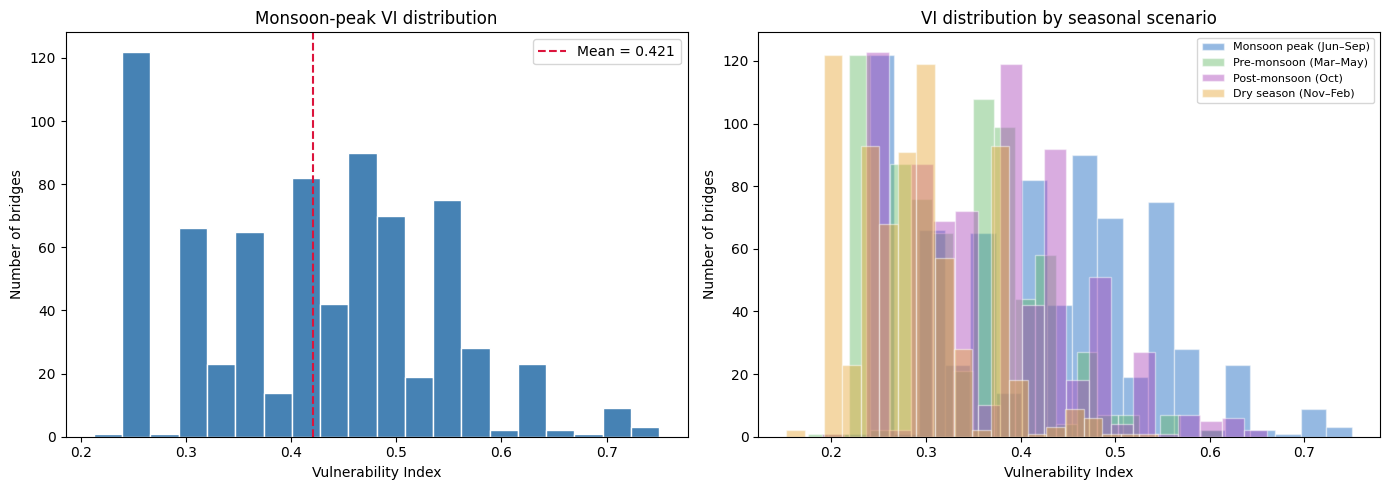

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: monsoon-peak distribution --------------------------------------
ax = axes[0]
ax.hist(df["Vulnerability index"], bins=20, edgecolor="white", color="steelblue")
ax.axvline(df["Vulnerability index"].mean(), color="crimson",
           linestyle="--", label=f"Mean = {df['Vulnerability index'].mean():.3f}")
ax.set_xlabel("Vulnerability Index")
ax.set_ylabel("Number of bridges")
ax.set_title("Monsoon-peak VI distribution")
ax.legend()

# --- Right: seasonal overlay ----------------------------------------------
# "Vulnerability index" represents monsoon peak (multipliers = 1.0).
# The three seasonal variants show how the distribution shifts when
# flood and erosion intensities are reduced outside the monsoon window.
ax = axes[1]
scenario_colors = {
    "Vulnerability index": ("#1565c0", "Monsoon peak (Jun–Sep)"),
    "VI_pre_monsoon":      ("#66bb6a", "Pre-monsoon (Mar–May)"),
    "VI_post_monsoon":     ("#ab47bc", "Post-monsoon (Oct)"),
    "VI_dry_season":       ("#e8a838", "Dry season (Nov–Feb)"),
}
for col, (color, label) in scenario_colors.items():
    ax.hist(df[col], bins=20, alpha=0.45, edgecolor="white", color=color, label=label)
ax.set_xlabel("Vulnerability Index")
ax.set_ylabel("Number of bridges")
ax.set_title("VI distribution by seasonal scenario")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Save output

In [9]:
output_path = "../data/vulnerability_index.csv"
df.to_csv(output_path, encoding="utf-8", index=False)
print(f"Saved {len(df)} rows to {output_path}")

Saved 738 rows to ../data/vulnerability_index.csv
